<a href="https://colab.research.google.com/github/stephenfrein/vucsc8491/blob/main/Week2_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualization

In this notebook, we'll explore principles and techniques for visualizing data in Python.

We'll cover:

* common tools (Matplotlib, Seaborn)
* when to use what kind of visualization
* general principles to follow
* things you should avoid doing
* less common techniques (e.g., 3D, animated, interactive)


## Matplotlib

This is the most common visualization tool in Python. It is a workhorse that other libraries like Seaborn and Pandas use to get graphical work done.

Its name comes from its inspiration - it was created as a tool for doing graphs similar to those in the proprietary MATLAB platform.

General script for using *matplotlib*:

* create a Figure (canvas on which you'll put your visualizations)
* create one or more plots (*"Axes"* in matplotlib-speak)
* plot your data
* add labeling
* show the figure

We'll start off using *matplotlib* and then re-introduce *seaborn* to show you how easy it makes visualizations.

In [ ]:
# let's graph the passenger classes for the Titanic

import pandas as pd
# get the titanic data so we can graph it
titanic_df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
# we did this in Week 1 - uses matplotlib underneath
titanic_df['Pclass'].value_counts().plot(kind='bar')

In [ ]:
class_summary = titanic_df['Pclass'].value_counts()
display(class_summary)
print('-----------')
type(class_summary)

In [ ]:
# let's do a more explicit version for deeper understanding and control

# pyplot is a module within matplotlib
# it allows for an assumed "current" figure to simplify code
# conventional to import it as plt
import matplotlib.pyplot as plt

# get counts by passenger class, sorted by class number
class_summary = titanic_df['Pclass'].value_counts().sort_index()
# this may look like a dataframe
print('class_summary contains:\n') # '\n' injects a new line
display(class_summary)
print('-----------')
# but it's really a series with the passenger classes as index values
print('the data type is:\n')
display(type(class_summary))
print('-----------')

# this means create a vertical bar chart
# first arg is list (see square brackets) of x-axis categories
# second arg is y-axis values
plt.bar(["First","Second","Third"], class_summary)
# the next line uses the "current" figure - the bar chart we just created
plt.title("Titanic Passengers by Class")
plt.show()

In [ ]:
# this will give you a unique list of unique index values
# for a Series if you don't want to bother coming up with other labels
class_summary.index.astype(str).to_list()


## ??? Reflection ???

What could we do to make the above figure better?

In [ ]:
# label the x and y axis

plt.bar(["First","Second","Third"], class_summary)
plt.xlabel("Passenger Class")         # label x-axis
plt.ylabel("Number of Passengers")    # label y-axis
plt.title("Titanic Passengers by Class")
plt.show()

In [ ]:
# bring grid lines across to make heights more readable

plt.bar(["First","Second","Third"], class_summary)
# extend lines for y axis and make these 60% transparent
plt.grid(axis='y', alpha=0.4)
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.title("Titanic Passengers by Class")
plt.show()

In [ ]:
# change coloring from default

plt.bar(["First","Second","Third"], class_summary,
        # different color for each class and defined edge
        color=["gold","steelblue","dimgray"],  edgecolor="black")
plt.grid(axis='y', alpha=0.4)
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.title("Titanic Passengers by Class")
plt.show()

In [ ]:
# add bar labels

bars = plt.bar(["First","Second","Third"], class_summary,
        color=["gold","steelblue","dimgray"],  edgecolor="black")
# bar labels added with padding to distance from edge of bar
plt.bar_label(bars, padding=4)
plt.grid(axis='y', alpha=0.4)
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.title("Titanic Passengers by Class")
plt.show()

In [ ]:
# increase y-axis range to give that top label more room

bars = plt.bar(["First","Second","Third"], class_summary,
        color=["gold","steelblue","dimgray"],  edgecolor="black")
# bar labels added with padding to distance from edge of bar
plt.bar_label(bars, padding=4)
plt.grid(axis='y', alpha=0.4)
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.title("Titanic Passengers by Class")
# bump up the top of y-axis to 600
plt.ylim(top=600)
plt.show()

In [ ]:
# you can also save to an image file - check the folder on the left
plt.savefig('titanic_pclass_bar_chart.png')

The above is just a taste of the kind of control you have - if you can imagine it, you can probably do it in *matplotlib*.

## Exercise 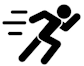

We'll do a visualization for the Ames Housing data...

In [ ]:
# get the Ames Housing dataset from last week (our modified version)
ah_df = pd.read_csv('https://csc8491.s3.us-east-1.amazonaws.com/Ames_Housing_Modified.csv')

# create a bar plot of the numbers of homes with each Bldg Type
# be sure to label the x and y axis and the bars
# if you need to increase the y axis to give room to the labels, do so

## Choosing a Visualization Type

Here are recommend graph types to use in various situations...

| Scenario | Chart type |
|---|---|
| Compare values across categories | Bar chart (maybe pie) |
| Understand a distribution | Histogram |
| Compare distributions across groups | Box plot |
| Relationship between two numeric variables | Scatter plot |
| Trends over time | Line chart |
| Correlation between many variables | Heatmap |
| Part-to-whole across groups | Stacked bar |
| Distribution shape (including bimodal) | Violin plot |

## Comparing Values Across Categories

Generally, bar charts are a better choice, but pie charts sometimes make sense.


In [ ]:
# comparing passenger class counts again

# load data and get counts
counts = titanic_df['Pclass'].value_counts().sort_index()

# create a figure with 1 row and 2 columns
# each of the columns will hold its own subplot (separate graph)
fig, (ax1, ax2) = plt.subplots(1, 2)
# overall figure title
fig.suptitle('Titanic Passengers by Class')

# simple bar chart for 1st plot
ax1.bar(counts.index.astype(str), counts.values) # x values, y values
ax1.set_title('Bar Chart\n(precise comparisons, absolute values)', fontsize=10)

# simple pie chart for 2nd plot
# size slices by counts, label by PClass, format %s
ax2.pie(counts.values, labels=counts.index.astype(str), autopct='%1.1f%%')
ax2.set_title('Pie Chart\n(parts-of-a-whole, relative proportions)', fontsize=10)

# semi-magical command that adjusts spacing to avoid overlap
plt.tight_layout()


## Understanding a Distribution

A histogram is a good way to see where values are concentrated.

In [ ]:
# we did one for fares in week 1 - let's do Age now

# create our figure and plotting surface
# figsize specifies width then height in *inches*
fig, ax = plt.subplots(figsize=(8, 4))
# remember from week 1 - bins is often square root of # of rows
ax.hist(titanic_df['Age'], bins=30)
# axvline is an "axes vertical line" - first arg is place on x-axis
ax.axvline(titanic_df['Age'].median(), color='crimson',
           # dashed line 1.5 points wide
           # a point is the same unit of measure in, say, a 10-point font
           linestyle='--', linewidth=1,
           # an f-string in Python is a formatted string literal
           # allows you to combine literal text and variables
           # variables go inside curly braces
           label=f"Median: {titanic_df['Age'].median()}")
ax.set_title('Age Distribution of Titanic Passengers')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
# this puts the legend on the graph (the top right)
ax.legend()
plt.tight_layout()
plt.show()

## Seaborn - Nice Plots with Less Effort

We saw seaborn (usually imported as sns) in week 1. It's built on top of matplotlib. It gives you nicer looking visuals with less effort than matplotlib (e.g., it will automatically add axis labels for you), so you should incline towards using it in many cases.

The name is nothing intuitive - it is named after a character in a TV show that the creator enjoyed. When we import it as *sns*, we are using that character's initials.

## Compare Distributions Across Groups

A histogram lets us see a variable's distribution, but how do we see the differences in its distribution based on some other factor?

Boxplots, which we saw in week 1, are a good tool for this.

In [ ]:
# boxplot with seaborn
import seaborn as sns
sns.boxplot(data=titanic_df, x='Pclass', y='Age')

In [ ]:
# this us gets to the same place in pure matplotlib
# notice it is a lot more code
import matplotlib.pyplot as plt

# group Age values by Pclass
groups = [
    titanic_df[titanic_df['Pclass'] == cls]['Age'].dropna()
    for cls in sorted(titanic_df['Pclass'].unique())
]

fig, ax = plt.subplots()
ax.boxplot(groups, tick_labels=sorted(titanic_df['Pclass'].unique()))

ax.set_xlabel('Pclass')
ax.set_ylabel('Age')
plt.tight_layout()
plt.show()

Seaborn did all of this behind the scenes:

1. finds unique Pclass values and sorts them
2. splits Age into one array per class (dropna included)
3. maps Pclass values to x-axis tick labels
4. calls the underlying boxplot with the grouped data

## Relationship Between Two Numeric Variables

We typically use a *scatteplot* to show the relationship between two numeric variables.

In [ ]:
# seaborn scatterplot
sns.scatterplot(data=titanic_df, x='Age', y='Fare')

In [ ]:
# add a third dimension with color (hue)
sns.scatterplot(data=titanic_df, x='Age', y='Fare', hue='Survived')
# also try it with Pclass in third dimension
